<a href="https://colab.research.google.com/github/dhafi7/finalterm_MachineLearning/blob/main/Regresi.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
from google.colab import drive
drive.mount('/content/drive')

!pip install -q pandas numpy matplotlib scikit-learn tensorflow optuna mlflow lime

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 49.7/49.7 kB 2.0 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 275.7/275.7 kB 9.4 MB/s eta 0:00:00
  Preparing metadata (setup.py) ... done
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 50.5/50.5 kB 4.3 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 43.7/43.7 kB 3.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 425.6/425.6 kB 21.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 12.6/12.6 MB 71.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 3.5/3.5 MB 72.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.7/1.7 MB 64.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 147.8/147.8 kB 13.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 114.9/114.9 kB 9.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━

In [2]:
import os
import warnings
warnings.filterwarnings("ignore")

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score

from sklearn.linear_model import LinearRegression
from sklearn.ensemble import RandomForestRegressor

import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Dropout, BatchNormalization
from tensorflow.keras.callbacks import EarlyStopping

import optuna

import mlflow
import mlflow.tensorflow

from lime.lime_tabular import LimeTabularExplainer

In [3]:
DATA_PATH = "/content/drive/MyDrive/Datasets ML 2/midterm-regresi-dataset.csv"

os.makedirs("reports_regression", exist_ok=True)
os.makedirs("models_regression", exist_ok=True)

In [4]:
df = pd.read_csv(DATA_PATH, header=None)

print("Dataset berhasil dibaca.")
print("Shape dataset:", df.shape)

df.head()

Dataset berhasil dibaca.
Shape dataset: (515345, 91)


,0,1,2,3,4,5,6,7,8,9,...,81,82,83,84,85,86,87,88,89,90
0,2001,49.94357,21.47114,73.07750,8.74861,-17.40628,-13.09905,-25.01202,-12.23257,7.83089,...,13.01620,-54.40548,58.99367,15.37344,1.11144,-23.08793,68.40795,-1.82223,-27.46348,2.26327
1,2001,48.73215,18.42930,70.32679,12.94636,-10.32437,-24.83777,8.76630,-0.92019,18.76548,...,5.66812,-19.68073,33.04964,42.87836,-9.90378,-32.22788,70.49388,12.04941,58.43453,26.92061
2,2001,50.95714,31.85602,55.81851,13.41693,-6.57898,-18.54940,-3.27872,-2.35035,16.07017,...,3.03800,26.05866,-50.92779,10.93792,-0.07568,43.20130,-115.00698,-0.05859,39.67068,-0.66345
3,2001,48.24750,-1.89837,36.29772,2.58776,0.97170,-26.21683,5.05097,-10.34124,3.55005,...,34.57337,-171.70734,-16.96705,-46.67617,-12.51516,82.58061,-72.08993,9.90558,199.62971,18.85382
4,2001,50.97020,42.20998,67.09964,8.46791,-15.85279,-16.81409,-12.48207,-9.37636,12.63699,...,9.92661,-55.95724,64.92712,-17.72522,-1.49237,-7.50035,51.76631,7.88713,55.66926,28.74903


In [5]:
num_columns = df.shape[1]

column_names = ["target_year"] + [f"feature_{i}" for i in range(1, num_columns)]

df.columns = column_names

print(df.columns[:10])
df.head()

Index(['target_year', 'feature_1', 'feature_2', 'feature_3', 'feature_4',
       'feature_5', 'feature_6', 'feature_7', 'feature_8', 'feature_9'],
      dtype='object')


,target_year,feature_1,feature_2,feature_3,feature_4,feature_5,feature_6,feature_7,feature_8,feature_9,...,feature_81,feature_82,feature_83,feature_84,feature_85,feature_86,feature_87,feature_88,feature_89,feature_90
0,2001,49.94357,21.47114,73.07750,8.74861,-17.40628,-13.09905,-25.01202,-12.23257,7.83089,...,13.01620,-54.40548,58.99367,15.37344,1.11144,-23.08793,68.40795,-1.82223,-27.46348,2.26327
1,2001,48.73215,18.42930,70.32679,12.94636,-10.32437,-24.83777,8.76630,-0.92019,18.76548,...,5.66812,-19.68073,33.04964,42.87836,-9.90378,-32.22788,70.49388,12.04941,58.43453,26.92061
2,2001,50.95714,31.85602,55.81851,13.41693,-6.57898,-18.54940,-3.27872,-2.35035,16.07017,...,3.03800,26.05866,-50.92779,10.93792,-0.07568,43.20130,-115.00698,-0.05859,39.67068,-0.66345
3,2001,48.24750,-1.89837,36.29772,2.58776,0.97170,-26.21683,5.05097,-10.34124,3.55005,...,34.57337,-171.70734,-16.96705,-46.67617,-12.51516,82.58061,-72.08993,9.90558,199.62971,18.85382
4,2001,50.97020,42.20998,67.09964,8.46791,-15.85279,-16.81409,-12.48207,-9.37636,12.63699,...,9.92661,-55.95724,64.92712,-17.72522,-1.49237,-7.50035,51.76631,7.88713,55.66926,28.74903


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 515345 entries, 0 to 515344
Data columns (total 91 columns):
 #   Column       Non-Null Count   Dtype  
---  ------       --------------   -----  
 0   target_year  515345 non-null  int64  
 1   feature_1    515345 non-null  float64
 2   feature_2    515345 non-null  float64
 3   feature_3    515345 non-null  float64
 4   feature_4    515345 non-null  float64
 5   feature_5    515345 non-null  float64
 6   feature_6    515345 non-null  float64
 7   feature_7    515345 non-null  float64
 8   feature_8    515345 non-null  float64
 9   feature_9    515345 non-null  float64
 10  feature_10   515345 non-null  float64
 11  feature_11   515345 non-null  float64
 12  feature_12   515345 non-null  float64
 13  feature_13   515345 non-null  float64
 14  feature_14   515345 non-null  float64
 15  feature_15   515345 non-null  float64
 16  feature_16   515345 non-null  float64
 17  feature_17   515345 non-null  float64
 18  feature_18   515345 non-

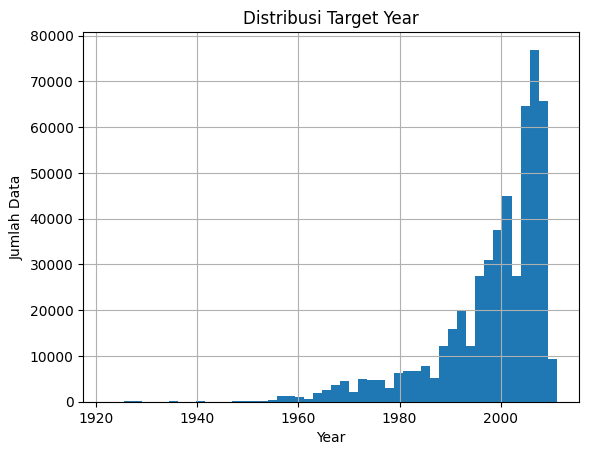

In [6]:
df.info()
df.describe()
print("Jumlah baris:", df.shape[0])
print("Jumlah kolom:", df.shape[1])
print("Jumlah fitur:", df.shape[1] - 1)
df["target_year"].describe()
plt.figure()
df["target_year"].hist(bins=50)
plt.title("Distribusi Target Year")
plt.xlabel("Year")
plt.ylabel("Jumlah Data")
plt.show()

In [7]:
missing_values = df.isnull().sum()

print("Total missing values:", missing_values.sum())

missing_values[missing_values > 0]

Total missing values: 0


,0


In [8]:
for col in df.columns:
    df[col] = pd.to_numeric(df[col], errors="coerce")

print(df.dtypes.value_counts())

print("Total missing values setelah convert numeric:", df.isnull().sum().sum())

float64    90
int64       1
Name: count, dtype: int64
Total missing values setelah convert numeric: 0


In [9]:
for col in df.columns:
    df[col] = df[col].fillna(df[col].median())

print("Total missing values setelah handling:", df.isnull().sum().sum())

Total missing values setelah handling: 0


In [10]:
print("Sebelum filtering:", df.shape)

df = df[(df["target_year"] >= 1900) & (df["target_year"] <= 2025)]

print("Setelah filtering target year:", df.shape)

Sebelum filtering: (515345, 91)
Setelah filtering target year: (515345, 91)


In [11]:
feature_cols = [col for col in df.columns if col != "target_year"]

for col in feature_cols:
    Q1 = df[col].quantile(0.25)
    Q3 = df[col].quantile(0.75)
    IQR = Q3 - Q1

    lower_bound = Q1 - 1.5 * IQR
    upper_bound = Q3 + 1.5 * IQR

    df[col] = np.where(df[col] < lower_bound, lower_bound, df[col])
    df[col] = np.where(df[col] > upper_bound, upper_bound, df[col])

print("Outlier capping selesai.")

Outlier capping selesai.


In [12]:
X = df.drop(columns=["target_year"])
y = df["target_year"]

print("Shape X:", X.shape)
print("Shape y:", y.shape)

Shape X: (515345, 90)
Shape y: (515345,)


In [13]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)

print("X_train:", X_train.shape)
print("X_test:", X_test.shape)
print("y_train:", y_train.shape)
print("y_test:", y_test.shape)

X_train: (412276, 90)
X_test: (103069, 90)
y_train: (412276,)
y_test: (103069,)


In [14]:
scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

print("Scaling selesai.")

Scaling selesai.


In [15]:
def evaluate_regression(y_true, y_pred, model_name):
    mse = mean_squared_error(y_true, y_pred)
    rmse = np.sqrt(mse)
    mae = mean_absolute_error(y_true, y_pred)
    r2 = r2_score(y_true, y_pred)

    results = {
        "Model": model_name,
        "MSE": mse,
        "RMSE": rmse,
        "MAE": mae,
        "R2": r2
    }

    print(f"Evaluation Result - {model_name}")
    print("MSE :", mse)
    print("RMSE:", rmse)
    print("MAE :", mae)
    print("R2  :", r2)

    return results

In [16]:
linear_model = LinearRegression()

linear_model.fit(X_train_scaled, y_train)

y_pred_linear = linear_model.predict(X_test_scaled)

results_linear = evaluate_regression(
    y_test,
    y_pred_linear,
    "Linear Regression"
)

Evaluation Result - Linear Regression
MSE : 88.77622156994971
RMSE: 9.422113434360133
MAE : 6.7022324229875805
R2  : 0.2540754810273097


In [18]:
from sklearn.ensemble import RandomForestRegressor

rf_model = RandomForestRegressor(
    n_estimators=30,
    max_depth=12,
    min_samples_split=10,
    min_samples_leaf=5,
    max_features="sqrt",
    random_state=42,
    n_jobs=-1
)

rf_model.fit(X_train, y_train)

y_pred_rf = rf_model.predict(X_test)

results_rf = evaluate_regression(
    y_test,
    y_pred_rf,
    "Random Forest Regressor Light"
)

Evaluation Result - Random Forest Regressor Light
MSE : 90.4203940284359
RMSE: 9.50896387775429
MAE : 6.837260834503718
R2  : 0.2402606494370949


In [19]:
input_dim = X_train_scaled.shape[1]

dl_model = Sequential([
    Dense(128, activation="relu", input_shape=(input_dim,)),
    Dense(64, activation="relu"),
    Dense(32, activation="relu"),
    Dense(1)
])

dl_model.compile(
    optimizer="adam",
    loss="mse",
    metrics=["mae"]
)

dl_model.summary()

early_stop = EarlyStopping(
    monitor="val_loss",
    patience=5,
    restore_best_weights=True
)

history_dl = dl_model.fit(
    X_train_scaled,
    y_train,
    validation_split=0.2,
    epochs=50,
    batch_size=256,
    callbacks=[early_stop],
    verbose=1
)

y_pred_dl = dl_model.predict(X_test_scaled).ravel()

results_dl = evaluate_regression(
    y_test,
    y_pred_dl,
    "Deep Learning MLP"
)

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense (Dense)                   │ (None, 128)            │        11,648 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 64)             │         8,256 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 32)             │         2,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 1)              │            33 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 22,017 (86.00 KB)

 Trainable params: 22,017 (86.00 KB)

 Non-trainable params: 0 (0.00 B)

Epoch 1/50
1289/1289 ━━━━━━━━━━━━━━━━━━━━ 7s 4ms/step - loss: 385999.6562 - mae: 374.6906 - val_loss: 30714.2500 - val_mae: 137.3363
Epoch 2/50
1289/1289 ━━━━━━━━━━━━━━━━━━━━ 6s 5ms/step - loss: 12129.8496 - mae: 78.8511 - val_loss: 1545.0452 - val_mae: 28.5808
Epoch 3/50
1289/1289 ━━━━━━━━━━━━━━━━━━━━ 5s 4ms/step - loss: 565.5860 - mae: 16.6133 - val_loss: 232.6330 - val_mae: 11.2584
Epoch 4/50
1289/1289 ━━━━━━━━━━━━━━━━━━━━ 5s 4ms/step - loss: 162.4361 - mae: 9.3501 - val_loss: 135.9711 - val_mae: 8.7121
Epoch 5/50
1289/1289 ━━━━━━━━━━━━━━━━━━━━ 7s 5ms/step - loss: 124.8576 - mae: 8.2685 - val_loss: 123.8761 - val_mae: 8.0839
Epoch 6/50
1289/1289 ━━━━━━━━━━━━━━━━━━━━ 5s 4ms/step - loss: 119.8174 - mae: 8.1520 - val_loss: 139.7636 - val_mae: 8.7088
Epoch 7/50
1289/1289 ━━━━━━━━━━━━━━━━━━━━ 5s 4ms/step - loss: 119.7099 - mae: 8.1520 - val_loss: 115.4762 - val_mae: 8.3610
Epoch 8/50
1289/1289 ━━━━━━━━━━━━━━━━━━━━ 7s 5ms/step - loss: 116.6030 - mae: 8.0486 - val_loss: 102.7554 - val_mae:

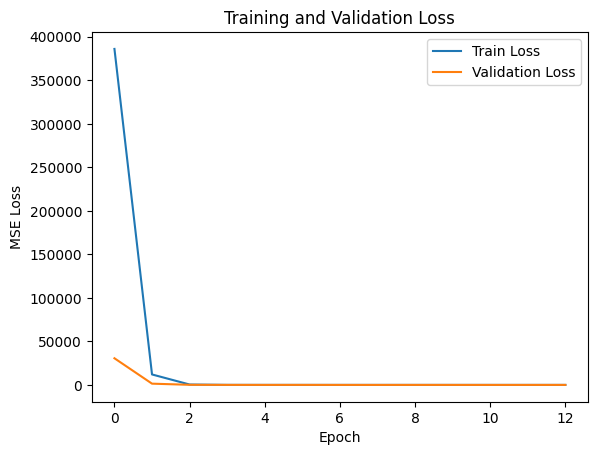

In [20]:
plt.figure()
plt.plot(history_dl.history["loss"], label="Train Loss")
plt.plot(history_dl.history["val_loss"], label="Validation Loss")
plt.title("Training and Validation Loss")
plt.xlabel("Epoch")
plt.ylabel("MSE Loss")
plt.legend()
plt.savefig("reports_regression/training_loss.png")
plt.show()

In [23]:
def objective(trial):
    tf.keras.backend.clear_session()

    n_units_1 = trial.suggest_int("n_units_1", 64, 256)
    n_units_2 = trial.suggest_int("n_units_2", 32, 128)
    n_units_3 = trial.suggest_int("n_units_3", 16, 64)
    dropout_rate = trial.suggest_float("dropout_rate", 0.1, 0.5)
    learning_rate = trial.suggest_float("learning_rate", 1e-4, 1e-2, log=True)
    batch_size = trial.suggest_categorical("batch_size", [128, 256, 512])

    model = Sequential([
        Dense(n_units_1, activation="relu", input_shape=(input_dim,)),
        BatchNormalization(),
        Dropout(dropout_rate),

        Dense(n_units_2, activation="relu"),
        BatchNormalization(),
        Dropout(dropout_rate),

        Dense(n_units_3, activation="relu"),
        Dense(1)
    ])

    optimizer = tf.keras.optimizers.Adam(learning_rate=learning_rate)

    model.compile(
        optimizer=optimizer,
        loss="mse",
        metrics=["mae"]
    )

    early_stop = EarlyStopping(
        monitor="val_loss",
        patience=3,
        restore_best_weights=True
    )

    history = model.fit(
        X_train_scaled,
        y_train,
        validation_split=0.2,
        epochs=10,
        batch_size=batch_size,
        callbacks=[early_stop],
        verbose=0
    )

    val_loss = min(history.history["val_loss"])

    return val_loss

study = optuna.create_study(direction="minimize")

study.optimize(objective, n_trials=5)

print("Best Parameters:")
print(study.best_trial.params)

print("Best Validation MSE:")
print(study.best_value)

[I 2026-06-19 15:49:00,527] A new study created in memory with name: no-name-80e1d048-9948-43d5-a222-f91dbb61dae0
[I 2026-06-19 15:52:19,403] Trial 0 finished with value: 484.0807189941406 and parameters: {'n_units_1': 147, 'n_units_2': 114, 'n_units_3': 19, 'dropout_rate': 0.29484056051589064, 'learning_rate': 0.00016402312790317398, 'batch_size': 128}. Best is trial 0 with value: 484.0807189941406.
[I 2026-06-19 15:54:48,867] Trial 1 finished with value: 330.677001953125 and parameters: {'n_units_1': 240, 'n_units_2': 105, 'n_units_3': 25, 'dropout_rate': 0.26972465700531295, 'learning_rate': 0.0008639970973177508, 'batch_size': 128}. Best is trial 1 with value: 330.677001953125.
[I 2026-06-19 15:56:06,121] Trial 2 finished with value: 483.4823303222656 and parameters: {'n_units_1': 111, 'n_units_2': 36, 'n_units_3': 24, 'dropout_rate': 0.22958256463226828, 'learning_rate': 0.0007819811378916128, 'batch_size': 128}. Best is trial 1 with value: 330.677001953125.
[I 2026-06-19 15:56:52

Best Parameters:
{'n_units_1': 240, 'n_units_2': 105, 'n_units_3': 25, 'dropout_rate': 0.26972465700531295, 'learning_rate': 0.0008639970973177508, 'batch_size': 128}
Best Validation MSE:
330.677001953125


In [24]:
best_params = study.best_trial.params

tf.keras.backend.clear_session()

best_model = Sequential([
    Dense(best_params["n_units_1"], activation="relu", input_shape=(input_dim,)),
    BatchNormalization(),
    Dropout(best_params["dropout_rate"]),

    Dense(best_params["n_units_2"], activation="relu"),
    BatchNormalization(),
    Dropout(best_params["dropout_rate"]),

    Dense(best_params["n_units_3"], activation="relu"),
    Dense(1)
])

optimizer = tf.keras.optimizers.Adam(
    learning_rate=best_params["learning_rate"]
)

best_model.compile(
    optimizer=optimizer,
    loss="mse",
    metrics=["mae"]
)

history_best = best_model.fit(
    X_train_scaled,
    y_train,
    validation_split=0.2,
    epochs=50,
    batch_size=best_params["batch_size"],
    callbacks=[early_stop],
    verbose=1
)

y_pred_best = best_model.predict(X_test_scaled).ravel()

results_best = evaluate_regression(
    y_test,
    y_pred_best,
    "Optuna Tuned Deep Learning MLP"
)

Epoch 1/50
2577/2577 ━━━━━━━━━━━━━━━━━━━━ 30s 11ms/step - loss: 738232.0000 - mae: 556.1887 - val_loss: 17422.0000 - val_mae: 62.6434
Epoch 2/50
2577/2577 ━━━━━━━━━━━━━━━━━━━━ 26s 10ms/step - loss: 32160.9922 - mae: 139.4775 - val_loss: 738.6447 - val_mae: 21.1317
Epoch 3/50
2577/2577 ━━━━━━━━━━━━━━━━━━━━ 19s 7ms/step - loss: 23015.3398 - mae: 120.3127 - val_loss: 571.3441 - val_mae: 19.4112
Epoch 4/50
2577/2577 ━━━━━━━━━━━━━━━━━━━━ 20s 8ms/step - loss: 19081.6465 - mae: 109.9050 - val_loss: 640.5925 - val_mae: 17.6734
Epoch 5/50
2577/2577 ━━━━━━━━━━━━━━━━━━━━ 21s 8ms/step - loss: 16845.3691 - mae: 103.5288 - val_loss: 820.0963 - val_mae: 23.7782
3221/3221 ━━━━━━━━━━━━━━━━━━━━ 5s 1ms/step
Evaluation Result - Optuna Tuned Deep Learning MLP
MSE : 17473.599609375
RMSE: 132.18774379410144
MAE : 62.282779693603516
R2  : -145.81845092773438


In [25]:
comparison = pd.DataFrame([
    results_linear,
    results_rf,
    results_dl,
    results_best
])

comparison

comparison.to_csv("reports_regression/regression_model_comparison.csv", index=False)

print("Model comparison berhasil disimpan.")

Model comparison berhasil disimpan.


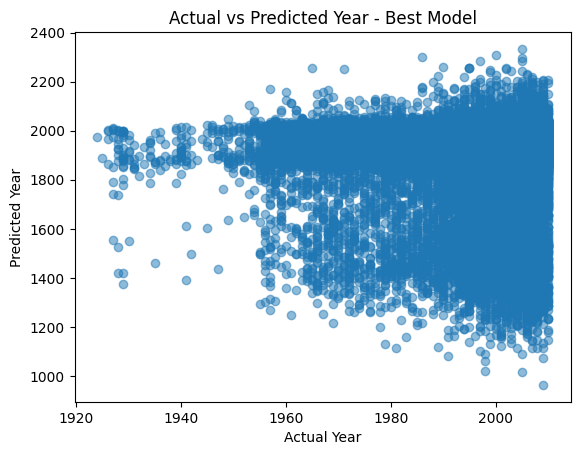

In [26]:
plt.figure()
plt.scatter(y_test, y_pred_best, alpha=0.5)
plt.xlabel("Actual Year")
plt.ylabel("Predicted Year")
plt.title("Actual vs Predicted Year - Best Model")
plt.savefig("reports_regression/actual_vs_predicted.png")
plt.show()

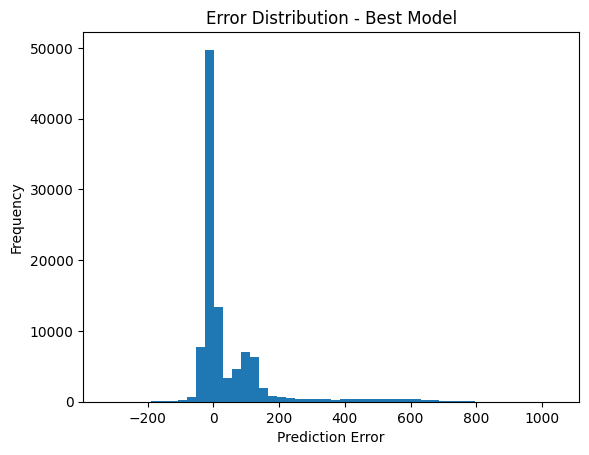

In [27]:
errors = y_test - y_pred_best

plt.figure()
plt.hist(errors, bins=50)
plt.xlabel("Prediction Error")
plt.ylabel("Frequency")
plt.title("Error Distribution - Best Model")
plt.savefig("reports_regression/error_distribution.png")
plt.show()

In [29]:
import os
from lime.lime_tabular import LimeTabularExplainer

os.makedirs("reports_regression", exist_ok=True)

feature_names = X.columns.tolist()

explainer = LimeTabularExplainer(
    training_data=X_train_scaled,
    feature_names=feature_names,
    mode="regression"
)

def predict_fn(data):
    return best_model.predict(data).ravel()

instance_index = 0

exp = explainer.explain_instance(
    data_row=X_test_scaled[instance_index],
    predict_fn=predict_fn,
    num_features=10
)

exp.show_in_notebook(show_table=True)

exp.save_to_file("reports_regression/lime_explanation.html")

print("LIME explanation berhasil disimpan.")

157/157 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step


LIME explanation berhasil disimpan.


In [30]:
lime_features = exp.as_list()

print("Top fitur berdasarkan LIME:")
for feature, weight in lime_features:
    print(feature, ":", weight)

Top fitur berdasarkan LIME:
feature_16 > 0.53 : -124.32719396854989
feature_10 > 0.67 : -50.41958997428292
feature_63 > 0.54 : -38.43921718610511
feature_35 > 0.59 : 38.2143035413135
feature_46 > 0.53 : -37.276296246293654
feature_11 > 0.62 : 36.076585906761885
feature_61 > 0.56 : -35.1430161718221
feature_56 > 0.53 : -34.437344051485624
feature_27 > 0.54 : 34.24445374591269
feature_43 > 0.60 : 33.11789263749506


In [31]:
mlflow.set_tracking_uri("sqlite:////content/mlflow_regression.db")

experiment_name = "regression_song_year_prediction"

if mlflow.get_experiment_by_name(experiment_name) is None:
    mlflow.create_experiment(
        experiment_name,
        artifact_location="file:///content/mlflow_regression_artifacts"
    )

mlflow.set_experiment(experiment_name)

with mlflow.start_run(run_name="Optuna_Tuned_Deep_Learning_Regression"):
    mlflow.log_params(best_params)

    mlflow.log_metric("mse", results_best["MSE"])
    mlflow.log_metric("rmse", results_best["RMSE"])
    mlflow.log_metric("mae", results_best["MAE"])
    mlflow.log_metric("r2_score", results_best["R2"])

    mlflow.tensorflow.log_model(best_model, "model")

    mlflow.log_artifact("reports_regression/regression_model_comparison.csv")
    mlflow.log_artifact("reports_regression/training_loss.png")
    mlflow.log_artifact("reports_regression/actual_vs_predicted.png")
    mlflow.log_artifact("reports_regression/error_distribution.png")
    mlflow.log_artifact("reports_regression/lime_explanation.html")

print("MLflow tracking selesai.")

2026/06/19 16:07:11 INFO mlflow.store.db.utils: Creating initial MLflow database tables...
2026/06/19 16:07:11 INFO mlflow.store.db.utils: Updating database tables
2026/06/19 16:07:15 WARNING mlflow.models.model: `artifact_path` is deprecated. Please use `name` instead.
2026/06/19 16:07:15 WARNING mlflow.tensorflow: You are saving a TensorFlow Core model or Keras model without a signature. Inference with mlflow.pyfunc.spark_udf() will not work unless the model's pyfunc representation accepts pandas DataFrames as inference inputs.


MLflow tracking selesai.


In [32]:
best_model.save("models_regression/best_regression_model.keras")

print("Best regression model berhasil disimpan.")

Best regression model berhasil disimpan.


In [33]:
import joblib

joblib.dump(scaler, "models_regression/scaler.pkl")

print("Scaler berhasil disimpan.")

Scaler berhasil disimpan.


In [34]:
OUTPUT_DIR = "/content/drive/MyDrive/finalterm-regression-result"

os.makedirs(OUTPUT_DIR, exist_ok=True)

!cp -r reports_regression "{OUTPUT_DIR}"
!cp -r models_regression "{OUTPUT_DIR}"
!cp -r /content/mlflow_regression.db "{OUTPUT_DIR}"
!cp -r /content/mlflow_regression_artifacts "{OUTPUT_DIR}"

print("Hasil regresi berhasil disimpan ke Google Drive.")

Hasil regresi berhasil disimpan ke Google Drive.


In [35]:
best_row = comparison.sort_values(by="RMSE").iloc[0]

print("Kesimpulan:")
print(f"Model terbaik berdasarkan RMSE adalah {best_row['Model']}.")
print(f"Nilai RMSE model terbaik adalah {best_row['RMSE']:.4f}.")
print(f"Nilai MAE model terbaik adalah {best_row['MAE']:.4f}.")
print(f"Nilai R2 model terbaik adalah {best_row['R2']:.4f}.")
print("RMSE menunjukkan rata-rata besar error prediksi dalam satuan tahun.")
print("MAE menunjukkan rata-rata selisih absolut antara tahun aktual dan tahun prediksi.")
print("R2 menunjukkan seberapa baik fitur audio mampu menjelaskan variasi target tahun lagu.")

Kesimpulan:
Model terbaik berdasarkan RMSE adalah Linear Regression.
Nilai RMSE model terbaik adalah 9.4221.
Nilai MAE model terbaik adalah 6.7022.
Nilai R2 model terbaik adalah 0.2541.
RMSE menunjukkan rata-rata besar error prediksi dalam satuan tahun.
MAE menunjukkan rata-rata selisih absolut antara tahun aktual dan tahun prediksi.
R2 menunjukkan seberapa baik fitur audio mampu menjelaskan variasi target tahun lagu.
